# Lab 03 - Redes Neuronales con TensorFlow/Keras
**Inteligencia Artificial 2026**

En este laboratorio diseñamos redes neuronales fully connected para clasificación y regresión.

In [55]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_digits, fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (confusion_matrix, classification_report,
                             accuracy_score, mean_squared_error,
                             mean_absolute_error, r2_score)
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.21.0


---
## Ejercicio 1: Clasificación de Dígitos (Scikit-Learn digits)

### Carga y exploración del dataset
El dataset `load_digits()` contiene 1,797 imágenes de 8x8 píxeles (64 atributos)
con valores entre 0 y 16. Hay 10 clases (dígitos del 0 al 9).

Shape de X: (1797, 64)
Shape de y: (1797,)
Clases: [0 1 2 3 4 5 6 7 8 9]
Rango de valores: 0.0 - 16.0


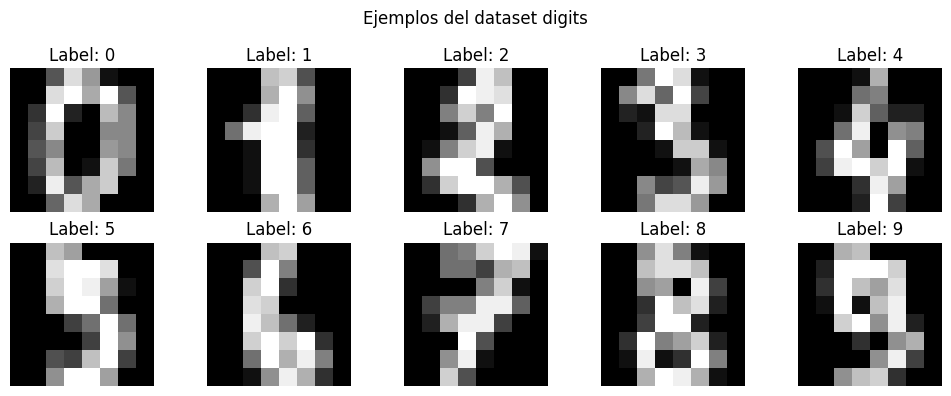

In [56]:
digits = load_digits()
X_digits = digits.data    # shape (1797, 64)
y_digits = digits.target   # shape (1797,)

print("Shape de X:", X_digits.shape)
print("Shape de y:", y_digits.shape)
print("Clases:", np.unique(y_digits))
print("Rango de valores:", X_digits.min(), "-", X_digits.max())

# Visualizar algunos ejemplos
fig, axes = plt.subplots(2, 5, figsize=(10, 4))
for i, ax in enumerate(axes.flat):
    ax.imshow(digits.images[i], cmap='gray')
    ax.set_title(f"Label: {y_digits[i]}")
    ax.axis('off')
plt.suptitle("Ejemplos del dataset digits")
plt.tight_layout()
plt.show()

### Preprocesamiento

**Normalización:** Dividimos los datos entre 16 (valor máximo de los píxeles)
para llevar los valores al rango [0, 1]. Esto ayuda a que la red converja
más rápido porque los gradientes se mantienen en escalas manejables.

**Etiquetas:** Convertimos las etiquetas a one-hot encoding porque estamos
usando `categorical_crossentropy` como función de pérdida, que espera
vectores de probabilidad como target.

In [57]:
X_norm = X_digits / 16.0  # normalizar al rango [0,1]

# One-hot encoding de las etiquetas
y_onehot = keras.utils.to_categorical(y_digits, num_classes=10)
print("Ejemplo one-hot para el digito", y_digits[0], ":", y_onehot[0])

Ejemplo one-hot para el digito 0 : [1. 0. 0. 0. 0. 0. 0. 0. 0. 0.]


### Partición Train/Test

Usamos 80% para entrenamiento y 20% para test. Con `stratify=y_digits`
nos aseguramos de que ambos conjuntos mantengan la misma proporción de
cada dígito, lo cual es importante para que el modelo entrene y se evalúe
de forma balanceada.

In [58]:
X_train, X_test, y_train, y_test = train_test_split(
    X_norm, y_onehot, test_size=0.2, random_state=42, stratify=y_digits
)

print(f"Train: {X_train.shape[0]} muestras")
print(f"Test:  {X_test.shape[0]} muestras")

Train: 1437 muestras
Test:  360 muestras


### Diseño de la Red Neuronal

**Arquitectura:** 2 capas ocultas con 128 y 64 neuronas respectivamente.

- Elegimos 128 neuronas en la primera capa para que la red pueda aprender
  representaciones ricas a partir de los 64 atributos de entrada.
- La segunda capa con 64 neuronas comprime la información antes de la salida.
- **ReLU** en capas ocultas: es la activación más usada porque evita el
  problema del gradiente desvaneciente y es computacionalmente eficiente.
- **Softmax** en la capa de salida: convierte las salidas en probabilidades
  que suman 1, ideal para clasificación multiclase.

**Hiperparámetros:**
- **Pérdida:** `categorical_crossentropy` porque es clasificación multiclase
  con etiquetas one-hot.
- **Optimizador:** Adam con learning rate 0.001 (valor por defecto que
  funciona bien en la mayoría de casos). Adam combina las ventajas de
  RMSProp y momentum.
- **Batch size:** 32, un buen balance entre velocidad y estabilidad del gradiente.
- **Epochs:** 50, suficientes para que la red converja sin sobreajustar.
- **Validación:** 15% del conjunto de entrenamiento para monitorear overfitting.

In [59]:
modelo_clf = keras.Sequential([
    layers.Input(shape=(64,)),
    layers.Dense(128, activation='relu'),
    layers.Dense(64, activation='relu'),
    layers.Dense(10, activation='softmax')
])

modelo_clf.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

modelo_clf.summary()

Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_21 (Dense)                │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_22 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_23 (Dense)                │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 17,226 (67.29 KB)

 Trainable params: 17,226 (67.29 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
historial_clf = modelo_clf.fit(
    X_train, y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.15,
    verbose=1
)

Epoch 1/50
39/39 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.4971 - loss: 1.9322 - val_accuracy: 0.7269 - val_loss: 1.5130
Epoch 2/50
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8600 - loss: 1.0182 - val_accuracy: 0.8102 - val_loss: 0.7513
Epoch 3/50
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9034 - loss: 0.4796 - val_accuracy: 0.9074 - val_loss: 0.4505
Epoch 4/50
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9312 - loss: 0.3007 - val_accuracy: 0.9444 - val_loss: 0.3116
Epoch 5/50
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9525 - loss: 0.2192 - val_accuracy: 0.9167 - val_loss: 0.2650
Epoch 6/50
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9623 - loss: 0.1738 - val_accuracy: 0.9583 - val_loss: 0.2128
Epoch 7/50
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9689 - loss: 0.1429 - val_accuracy: 0.9630 - val_loss: 0.1903
Epoch 8/50
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9779 - loss: 0.1200 - val_accuracy: 0.9491 - val_loss:

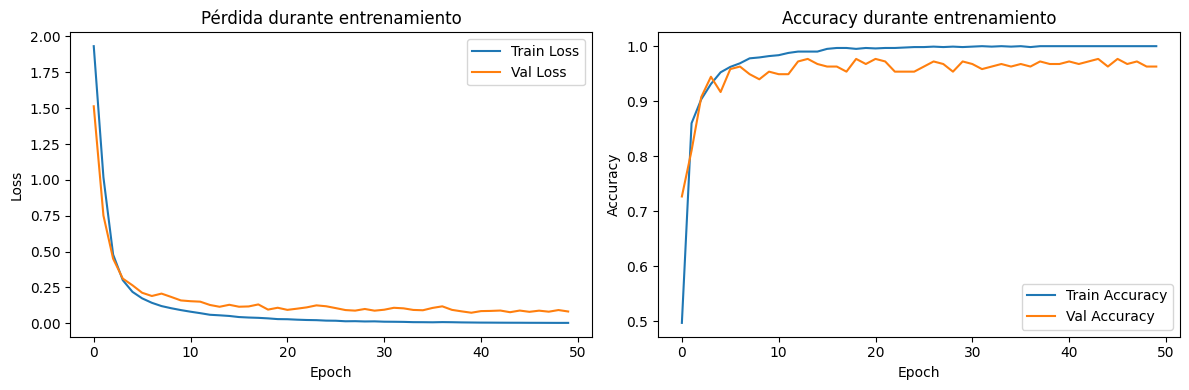

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(historial_clf.history['loss'], label='Train Loss')
ax1.plot(historial_clf.history['val_loss'], label='Val Loss')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.set_title('Pérdida durante entrenamiento')
ax1.legend()

ax2.plot(historial_clf.history['accuracy'], label='Train Accuracy')
ax2.plot(historial_clf.history['val_accuracy'], label='Val Accuracy')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy')
ax2.set_title('Accuracy durante entrenamiento')
ax2.legend()

plt.tight_layout()
plt.show()

### Evaluación del Modelo

In [ ]:
loss_train, acc_train = modelo_clf.evaluate(X_train, y_train, verbose=0)
loss_test, acc_test = modelo_clf.evaluate(X_test, y_test, verbose=0)

print("Métricas de Desempeño")
print(f"Train - Loss: {loss_train:.4f}, Accuracy: {acc_train:.4f}")
print(f"Test  - Loss: {loss_test:.4f},  Accuracy: {acc_test:.4f}")

# Predicciones
y_pred_prob = modelo_clf.predict(X_test)
y_pred = np.argmax(y_pred_prob, axis=1)
y_true = np.argmax(y_test, axis=1)

print("\nClassification Report (Test)")
print(classification_report(y_true, y_pred, digits=4))

Métricas de Desempeño
Train - Loss: 0.0145, Accuracy: 0.9944
Test  - Loss: 0.0627,  Accuracy: 0.9750
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 

Classification Report (Test)
              precision    recall  f1-score   support

           0     1.0000    1.0000    1.0000        36
           1     0.9211    0.9722    0.9459        36
           2     0.9722    1.0000    0.9859        35
           3     1.0000    0.9730    0.9863        37
           4     1.0000    1.0000    1.0000        36
           5     0.9737    1.0000    0.9867        37
           6     0.9722    0.9722    0.9722        36
           7     0.9474    1.0000    0.9730        36
           8     0.9677    0.8571    0.9091        35
           9     1.0000    0.9722    0.9859        36

    accuracy                         0.9750       360
   macro avg     0.9754    0.9747    0.9745       360
weighted avg     0.9755    0.9750    0.9747       360



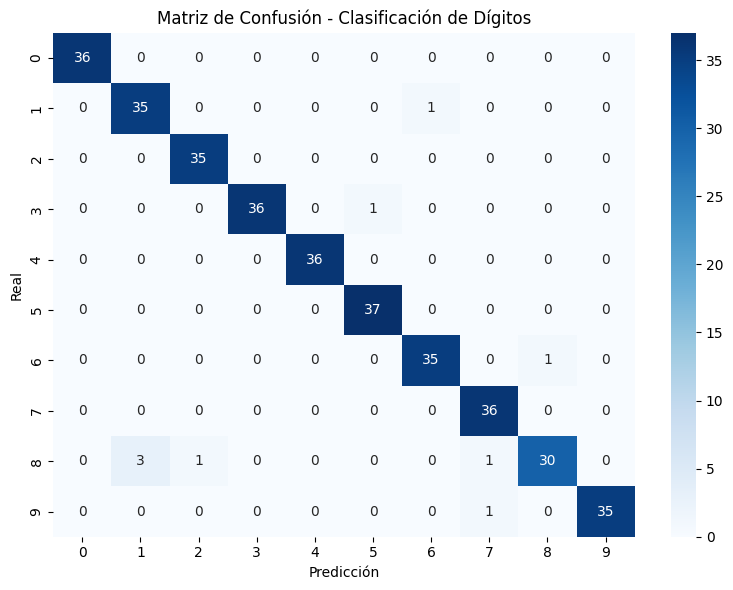

In [ ]:
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=range(10), yticklabels=range(10))
plt.xlabel('Predicción')
plt.ylabel('Real')
plt.title('Matriz de Confusión - Clasificación de Dígitos')
plt.tight_layout()
plt.show()

# Se puede observar que los errores más comunes son entre dígitos visualmente
# similares, como el 1 con el 7, o el 3 con el 8.

### Ejemplos de clasificaciones correctas e incorrectas

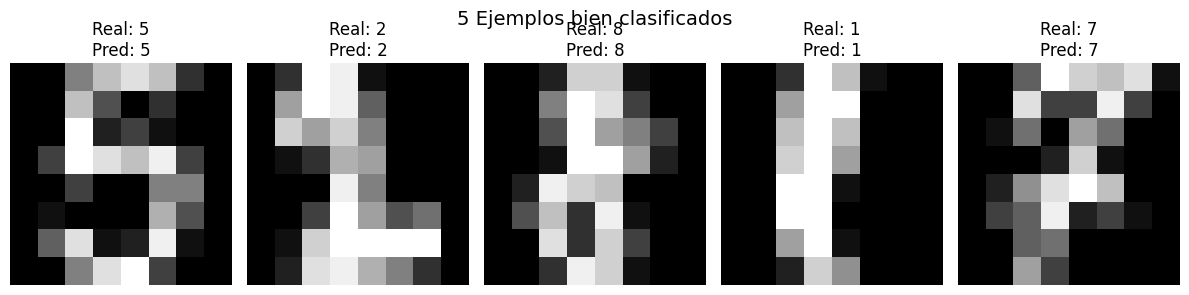

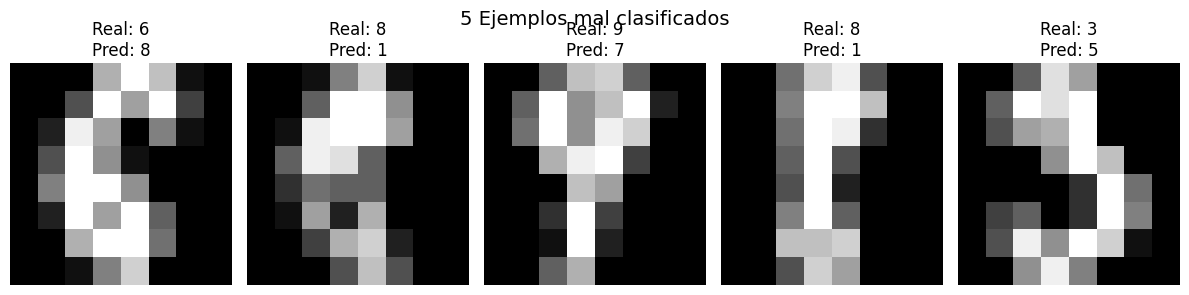

In [ ]:
correctos = np.where(y_pred == y_true)[0]
incorrectos = np.where(y_pred != y_true)[0]

# 5 bien clasificados
fig, axes = plt.subplots(1, 5, figsize=(12, 3))
fig.suptitle("5 Ejemplos bien clasificados", fontsize=14)
for i, ax in enumerate(axes):
    idx = correctos[i]
    img = X_test[idx].reshape(8, 8)
    ax.imshow(img, cmap='gray')
    ax.set_title(f"Real: {y_true[idx]}\nPred: {y_pred[idx]}")
    ax.axis('off')
plt.tight_layout()
plt.show()

# 5 mal clasificados
fig, axes = plt.subplots(1, 5, figsize=(12, 3))
fig.suptitle("5 Ejemplos mal clasificados", fontsize=14)
n_mostrar = min(5, len(incorrectos))
for i in range(n_mostrar):
    idx = incorrectos[i]
    img = X_test[idx].reshape(8, 8)
    axes[i].imshow(img, cmap='gray')
    axes[i].set_title(f"Real: {y_true[idx]}\nPred: {y_pred[idx]}")
    axes[i].axis('off')
# si hay menos de 5 errores, ocultar ejes restantes
for i in range(n_mostrar, 5):
    axes[i].axis('off')
plt.tight_layout()
plt.show()

if len(incorrectos) < 5:
    print(f"Nota: solo se encontraron {len(incorrectos)} errores de clasificación.")